# T08 — AR Model (AutoRegressive) — Book: CH05

**Methodology**: Marco Peixeiro, *Time Series Forecasting in Python*, Chapter 5.

### Book-mandated steps:
1. ADF stationarity test on health_index (level + first difference)
2. ACF and PACF plots to visually determine lag order p
3.  — select p by lowest AIC via SARIMAX(order=(p,0,0))
4. Fit best model → Ljung-Box residual test
5.  — walk-forward validation on representative engine
6. Full-dataset prediction → evaluate with RMSE + NASA score

In [1]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial

# Book imports — exactly as CH05 uses them
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from src.models.classical import (
    load_and_prepare,
    run_stationarity_report, plot_acf_pacf_multi, smooth_series,
    select_best_ar_order, _get_representative_engine,
    check_residuals, rolling_forecast_engine,
    predict_rul_ar_with_ci, predict_dataset_with_ci,
    validate_model_rolling,
)
from src.evaluation.metrics import evaluate

PROC_DIR    = ROOT / "data" / "processed"
RAW_PATH    = str(ROOT / "data" / "raw" / "train_FD004.txt")
# 16 sensors retained after T04 variance filter (dropped s1, s5, s16, s18, s19)
SENSOR_COLS = [f"s{i}" for i in [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 20, 21]]

## 1. Load data and build health_index

In [3]:
train, test, THRESHOLD = load_and_prepare(PROC_DIR, SENSOR_COLS)

Loaded: train=(61249, 123), test=(41214, 123)
Engines: train=249, test=248
  Degradation-correlation filter (|r| ≥ 0.5):
    Kept    9 sensors: ['s2', 's3', 's4', 's8', 's9', 's11', 's13', 's14', 's17']
    Dropped  7 sensors: ['s6', 's7', 's10', 's12', 's15', 's20', 's21']
  PCA fit on 61249 rows, 9 sensors (|r|≥0.5)
  PC1 explains 76.3% of within-condition variance  (using 9/16 sensors, |r|≥0.5)
  RUL regressor (all data): RUL = -5.19 * hi + 0.00  (R²=-5.189)
  RUL regressor (recent 60%): RUL = -29.69 * hi + 82.68  (R2=0.651)

Failure threshold (q=0.05): 1.4117
Health index range: [-1.531, 6.471]


## 2. Stationarity check — ADF test (CH03 methodology)

Book rule: run ADF at level + first difference. If level p > 0.05 and diff-1 p < 0.05 → d=1.
Here we check a stratified sample across ALL 4 FD subsets, not just 6 engines from FD001.

In [4]:
stationarity_df = run_stationarity_report(train, n_engines=248)
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\nNew MODAL_D = {MODAL_D}")


Stationarity Report (ADF test per sampled engine):
engine_id   level_p     diff1_p     rec_d
--------------------------------------------
1           0.9991      0.9931      2.0
2           1.0         0.7229      2.0
3           1.0         0.4577      2.0
4           1.0         0.1697      2.0
5           1.0         0.9941      2.0
6           1.0         0.9811      2.0
7           0.9968      0.0         1.0
8           1.0         0.903       2.0
9           1.0         0.4393      2.0
10          1.0         0.8217      2.0
11          1.0         0.0         1.0
12          1.0         0.6955      2.0
13          1.0         0.0012      1.0
14          1.0         0.992       2.0
15          1.0         0.9545      2.0
16          0.9982      0.9014      2.0
17          1.0         0.9867      2.0
18          1.0         0.9836      2.0
19          0.9954      0.0         1.0
20          1.0         0.7308      2.0
21          1.0         0.6441      2.0
22          1.0      

In [5]:
d_counts = stationarity_df["recommended_d"].value_counts().sort_index()
print(d_counts.to_string())
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\n→ MODAL_D = {MODAL_D}")

recommended_d
1     59
2    189

→ MODAL_D = 2


## 3. ACF and PACF plots (CH05 methodology)

Book rule: PACF cuts off at lag p → AR order.
Plot on smoothed health_index (smoothing is applied before fitting in production too).

 length: 61249 cycles


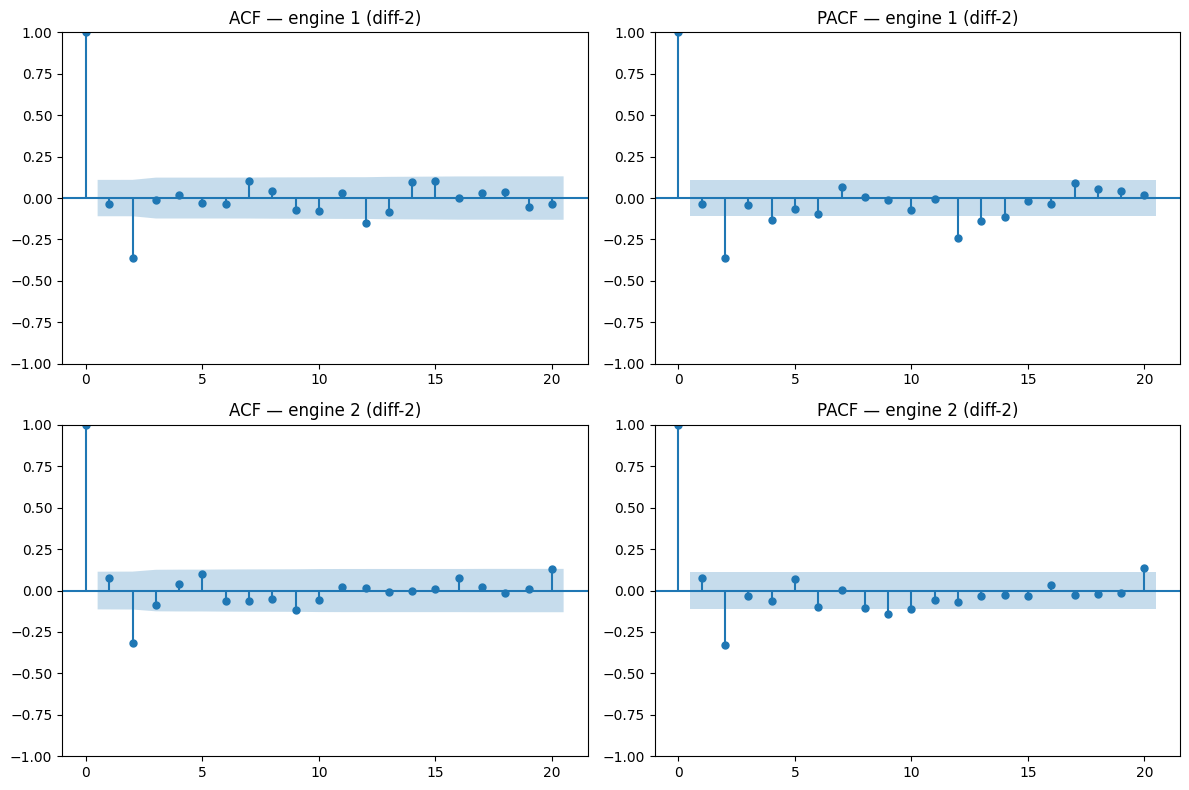

Reading: PACF cuts off at lag p → candidate AR(p)


In [6]:
# Pick one representative engine from FD001 to show ACF/PACF
raw   = train.sort_values("cycle").health_index.values
smth  = smooth_series(raw, window=5)

print(f" length: {len(smth)} cycles")
plot_acf_pacf_multi(train, d=MODAL_D, n_engines=2, lags=20)
print("Reading: PACF cuts off at lag p → candidate AR(p)")

## 4. Optimize AR order by AIC (CH05/CH06 pattern)

Book rule: run optimize function, sort by AIC ascending, pick lowest.

In [7]:
BEST_P = select_best_ar_order(train, d=MODAL_D, n_engines=15)

  engine 1: best p=2  (AIC=-1749.17)
  engine 2: best p=2  (AIC=-1832.05)
  engine 3: best p=5  (AIC=-1774.09)
  engine 4: best p=3  (AIC=-1403.53)
  engine 5: best p=4  (AIC=-1055.86)
  engine 6: best p=4  (AIC=-1788.02)
  engine 7: best p=2  (AIC=-1244.4)
  engine 8: best p=2  (AIC=-1347.9)
  engine 9: best p=2  (AIC=-1877.76)
  engine 10: best p=2  (AIC=-1748.93)
  engine 11: best p=2  (AIC=-1815.07)
  engine 12: best p=10  (AIC=-1181.45)
  engine 13: best p=2  (AIC=-1410.06)
  engine 14: best p=10  (AIC=-1356.37)
  engine 15: best p=4  (AIC=-1160.99)

→ Modal best AR order: p=2  (from 15 engines, freq=[(2, 8), (4, 3), (10, 2), (5, 1), (3, 1)])


## 5. Fit best AR model and check residuals (Ljung-Box)

Book rule (CH06/CH07): always run Ljung-Box after fitting. All p-values > 0.05 = white-noise residuals = adequate model.

In [8]:
rep_eid, rep_smth = _get_representative_engine(train)
# WHY: SARIMAX(p, d, 0) — SARIMAX handles d internally so forecast preserves trend
# Fit on last RECENT_WINDOW cycles (recent degradation is most informative)
from src.models.classical import RECENT_WINDOW
fit_series = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
model_fit = SARIMAX(fit_series, order=(BEST_P, MODAL_D, 0),
                    simple_differencing=False).fit(disp=False)
print(model_fit.summary())
lb_result = check_residuals(model_fit.resid, model_name=f"AR({BEST_P})")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   50
Model:               SARIMAX(2, 2, 0)   Log Likelihood                 115.426
Date:                Sat, 02 May 2026   AIC                           -224.853
Time:                        11:27:05   BIC                           -219.239
Sample:                             0   HQIC                          -222.731
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0206      0.187     -0.110      0.912      -0.388       0.347
ar.L2         -0.3760      0.154     -2.434      0.015      -0.679      -0.073
sigma2         0.0005      0.000      4.364      0.0

## 6. Rolling forecast on representative engine (CH05 pattern)

Book rule: walk-forward validation — refit at each window step, predict out-of-sample.

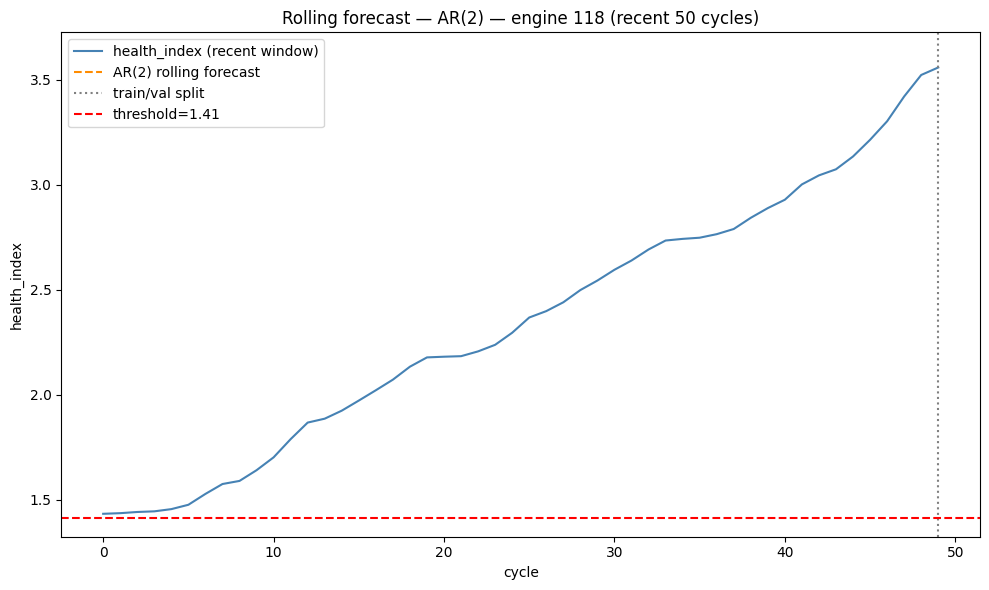

Rolling forecast RMSE: 0.0582


In [9]:
TRAIN_LEN = int(len(rep_smth) * 0.7)
WINDOW    = 1

# WHY: SARIMAX(p, d, 0) on original smoothed series (trend-preserving AR)
from src.models.classical import RECENT_WINDOW
fit_series    = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
diff_train_len = min(TRAIN_LEN, len(fit_series) - 1)

pred_ar = rolling_forecast_engine(
    series=fit_series, train_len=diff_train_len,
    order=(BEST_P, MODAL_D, 0),
    window=WINDOW,
)

actual_val = fit_series[diff_train_len: diff_train_len + len(pred_ar)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fit_series, color="steelblue", label="health_index (recent window)")
ax.plot(range(diff_train_len, diff_train_len + len(pred_ar)), pred_ar,
        color="darkorange", ls="--", label=f"AR({BEST_P}) rolling forecast")
ax.axvline(diff_train_len, color="gray", ls=":", label="train/val split")
ax.axhline(THRESHOLD, color="red", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
ax.set_title(f"Rolling forecast — AR({BEST_P}) — engine {rep_eid} (recent {RECENT_WINDOW} cycles)")
ax.legend(); plt.tight_layout(); plt.show()

rmse_roll = float(np.sqrt(np.mean((actual_val - pred_ar)**2)))
print(f"Rolling forecast RMSE: {rmse_roll:.4f}")

## 7. Full test-set evaluation

In [10]:
from functools import partial
predict_fn = partial(predict_rul_ar_with_ci, p=BEST_P, pre_diff_d=MODAL_D)
y_true, y_pred, y_lower, y_upper, engine_ids = predict_dataset_with_ci(
    test, predict_fn, THRESHOLD, verbose_engines=True
)
evaluate(y_true, y_pred, model_name=f"AR({BEST_P})")


  engine    1  true=  22.0  pred=  22.0  [ 13.0,  31.7]  err=+0.0
  engine    2  true=  39.0  pred=  14.0  [  9.0,  60.7]  err=-25.0
  engine    3  true= 107.0  pred= 109.9  [ 92.0, 109.9]  err=+2.9
  engine    4  true=  75.0  pred= 110.6  [ 79.0, 110.6]  err=+35.6
  engine    5  true= 125.0  pred=  79.1  [ 44.0,  79.1]  err=-45.9
  engine    6  true=  78.0  pred= 109.2  [ 92.0, 109.2]  err=+31.2
  engine    7  true=  94.0  pred= 124.0  [ 43.0, 125.0]  err=+30.0
  engine    8  true=  14.0  pred=   0.0  [  0.0,   0.0]  err=-14.0
  engine    9  true=  99.0  pred= 108.0  [ 57.0, 108.0]  err=+9.0
  engine   10  true= 125.0  pred= 111.7  [ 89.0, 111.7]  err=-13.3
  engine   11  true= 125.0  pred= 125.0  [ 43.0, 125.0]  err=+0.0
  engine   12  true=   7.0  pred=   0.0  [  0.0,   0.0]  err=-7.0
  engine   13  true=  71.0  pred= 125.0  [ 30.0, 125.0]  err=+54.0
  engine   14  true= 105.0  pred=  98.3  [ 67.0,  98.3]  err=-6.7
  engine   15  true=  12.0  pred=   3.0  [  3.0,   3.0]  err=-9.0
  

{'rmse': 30.901655197143555,
 'nasa_score': 24718.87109375,
 'nasa_score_mean': 99.67286731350806,
 'r2_score': 0.48309892416000366,
 'bias': -3.9299774169921875}

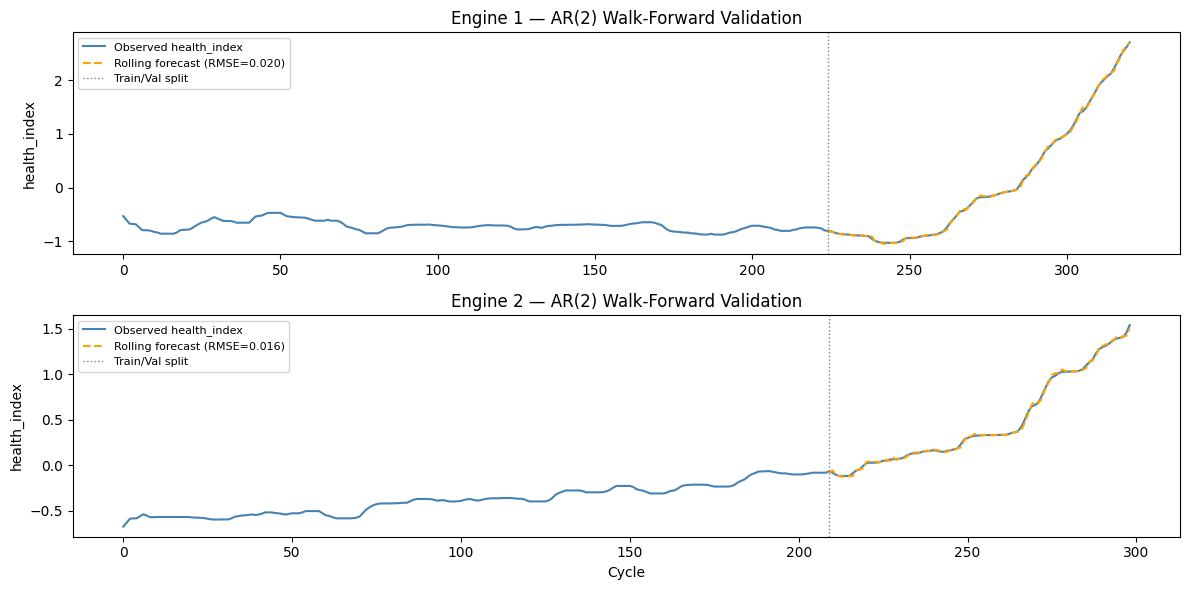


AR(2) Walk-Forward Validation Summary
Engines validated : 2
Mean RMSE         : 0.0183
Std RMSE          : 0.0022
Best engine RMSE  : 0.0161
Worst engine RMSE : 0.0205


In [11]:
val_rmse = validate_model_rolling(
    train      = train,
    order      = (BEST_P, MODAL_D, 0),   # AR: q=0
    n_engines  = 2,
    model_name = f"AR({BEST_P})"
)

In [12]:
from src.evaluation.metrics import save_model_results
save_model_results(
    model_name = f"AR({BEST_P})",
    model_type = "classical",
    y_true     = y_true,
    y_pred     = y_pred,
    y_lower    = y_lower,
    y_upper    = y_upper,
)


  [AR(2)] RMSE: 30.9017  |  NASA Score: 24718.87 (mean: 99.67)  |  R2: 0.4831  |  Bias: -3.93 (early ↓)
  → Saved to results/all_model_results.csv


{'rmse': 30.901655197143555,
 'nasa_score': 24718.87109375,
 'nasa_score_mean': 99.67286731350806,
 'r2_score': 0.48309892416000366,
 'bias': -3.9299774169921875}

In [13]:
from src.evaluation.metrics import save_predictions_csv

save_predictions_csv(
    engine_ids = engine_ids,
    y_true     = y_true,
    y_pred     = y_pred,
    y_lower    = y_lower,
    y_upper    = y_upper,
    model_name = f"AR({BEST_P})",
)



  [AR(2)] Bound Validation Report (248 engines):
    ✓ negative_preds: 0
    ✓ over_cap_preds: 0
    ✓ inverted_bounds: 0
    ✓ pred_outside_interval: 0
    ✓ nan_or_inf: 0
    → All checks passed — predictions are numerically valid.
  → Saved 248 predictions to results/predictions/AR2.csv
     Coverage: 55.2%  |  Avg interval width: 50.17 cycles


PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/predictions/AR2.csv')